
# Flight Delays — Vanilla ANN (Training)

**Objetivo:** Entrenar un MLP (ANN) multi‑salida para predecir minutos de demora por causa.

Incluye:
- Features históricas **sin fuga** (solo con TRAIN) y luego asignadas a VAL/TEST.
- Normalización (`StandardScaler`).
- Modelo robusto (Huber + L2 + Dropout) con **salida no negativa** (*Softplus*).
- Callbacks: *EarlyStopping*, *ReduceLROnPlateau*, *ModelCheckpoint*.
- Guardado de artefactos (modelo, scaler, tablas lookup, metadata).


In [ ]:

# 0) Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

# 1) Imports
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

np.random.seed(42); tf.random.set_seed(42)


In [ ]:

# 2) Paths
BASE = "/content/drive/MyDrive/DeepLearning_Project"
DATA_DIR = f"{BASE}/data"
MODELS_DIR = f"{BASE}/models"
OUT_DIR = f"{BASE}/outputs"
os.makedirs(MODELS_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)


In [ ]:

# 3) Load CSV
import os

def autodetect_csv(data_dir: str) -> str:
    for root, _, files in os.walk(data_dir):
        for f in files:
            if f.lower().endswith('.csv'):
                return os.path.join(root, f)
    raise FileNotFoundError('No se encontró CSV en ' + data_dir)

csv_path = f"{DATA_DIR}/DelayFlights-cleaned-handpick.csv"
if not os.path.exists(csv_path):
    csv_path = autodetect_csv(DATA_DIR)
print("CSV:", csv_path)

NROWS = 300_000  # empieza con subset; luego sube cuando todo esté estable
df = pd.read_csv(csv_path, nrows=NROWS).reset_index(drop=True)
print('df.shape =', df.shape)
df.head()


CSV: /content/drive/MyDrive/DeepLearning_Project/data/DelayFlights-cleaned.csv
df.shape = (300000, 16)


,Departure Block Hour,Arrival Time Block,Day Of Week,Flight Date,Origin Airport Code,Destination Airport Code,Fly Time Scheduled,Distance Miles,Distance Group,Carrier Delay,Weather Delay,Airport Delay,Security Delay,Late Aircraft Delay,Day of Month,Month
0,6,6,1,2023-02-13,144,217,65,137,1,0,0,0,0,0,13,2
1,6,7,1,2023-02-06,176,57,80,220,1,0,0,0,0,0,6,2
2,6,7,1,2023-02-06,250,57,60,159,1,0,0,0,0,0,6,2
3,6,7,1,2023-02-06,160,88,65,239,1,0,0,0,0,0,6,2
4,6,7,1,2023-02-06,81,160,60,187,1,0,0,0,0,0,6,2


In [ ]:

# 4) Targets (acepta alias con o sin espacio)
aliases = {
    "CarrierDelay":      ["CarrierDelay","Carrier Delay"],
    "WeatherDelay":      ["WeatherDelay","Weather Delay"],
    "AirportDelay":      ["AirportDelay","Airport Delay"],
    "SecurityDelay":     ["SecurityDelay","Security Delay"],
    "LateAircraftDelay": ["LateAircraftDelay","Late Aircraft Delay"]
}

def find_col(cands):
    for c in cands:
        if c in df.columns: return c
    return None

target_cols = [find_col(v) for v in aliases.values()]
assert all(target_cols), f"No se hallaron todos los targets. Encontrados: {target_cols}"
print('Targets:', target_cols)


Targets: ['Carrier Delay', 'Weather Delay', 'Airport Delay', 'Security Delay', 'Late Aircraft Delay']


In [ ]:

# 5) Temporal split: TRAIN / VAL / TEST
train_df, temp_df = train_test_split(df, test_size=0.30, shuffle=False)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, shuffle=False)
print(train_df.shape, val_df.shape, test_df.shape)


(210000, 16) (45000, 16) (45000, 16)


In [ ]:

# 6) Leakage-free historical features
key_aliases = {
    "airline_code":      ["airline_code","AirlineCode","carrier","Carrier"],
    "month":             ["month","Month"],
    "origin_city":       ["origin_city","OriginCity","origin"],
    "destination":       ["destination","Destination","dest"],
    "day_of_week":       ["day_of_week","DayOfWeek"],
    "depart_time_block": ["depart_time_block","DepartTimeBlock"]
}

def resolve_key(name):
    for c in key_aliases[name]:
        if c in df.columns: return c
    return None

keys = {k: resolve_key(k) for k in key_aliases}
keys

# total_delay
affected_parts = (train_df, val_df, test_df)
for part in affected_parts:
    part["total_delay"] = part[target_cols].sum(axis=1)

# route
if keys["origin_city"] and keys["destination"]:
    for part in affected_parts:
        part["route"] = part[keys["origin_city"]].astype(str) + "_" + part[keys["destination"]].astype(str)
else:
    for part in affected_parts:
        part["route"] = "UNK"

# Build historical lookups strictly from TRAIN
hist_tables = {}
if keys["airline_code"] and keys["month"]:
    t = train_df.groupby([keys["airline_code"], keys["month"]])["total_delay"].mean().reset_index()
    t.rename(columns={"total_delay":"feat_airline_month_mean"}, inplace=True)
    hist_tables["airline_month"] = t
if keys["origin_city"] and keys["depart_time_block"]:
    t = train_df.groupby([keys["origin_city"], keys["depart_time_block"]])["total_delay"].mean().reset_index()
    t.rename(columns={"total_delay":"feat_origin_slot_mean"}, inplace=True)
    hist_tables["origin_slot"] = t
if "route" in train_df.columns and keys["day_of_week"]:
    t = train_df.groupby(["route", keys["day_of_week"]])["total_delay"].mean().reset_index()
    t.rename(columns={"total_delay":"feat_route_dow_mean"}, inplace=True)
    hist_tables["route_dow"] = t

# Save lookups
BASE = "/content/drive/MyDrive/DeepLearning_Project"
MODELS_DIR = f"{BASE}/models"
import os
os.makedirs(MODELS_DIR, exist_ok=True)
if "airline_month" in hist_tables:
    hist_tables["airline_month"].to_csv(f"{MODELS_DIR}/feats_airline_month.csv", index=False)
if "origin_slot" in hist_tables:
    hist_tables["origin_slot"].to_csv(f"{MODELS_DIR}/feats_origin_slot.csv", index=False)
if "route_dow" in hist_tables:
    hist_tables["route_dow"].to_csv(f"{MODELS_DIR}/feats_route_dow.csv", index=False)

# Attach lookups to each split y filling missing NaN with TRAIN global mean
global_mean = float(train_df["total_delay"].mean())

def attach_feats(part):
    out = part.copy()
    if "airline_month" in hist_tables and keys["airline_code"] and keys["month"]:
        out = out.merge(hist_tables["airline_month"], on=[keys["airline_code"], keys["month"]], how='left')
    if "origin_slot" in hist_tables and keys["origin_city"] and keys["depart_time_block"]:
        out = out.merge(hist_tables["origin_slot"], on=[keys["origin_city"], keys["depart_time_block"]], how='left')
    if "route_dow" in hist_tables and keys["day_of_week"]:
        out = out.merge(hist_tables["route_dow"], on=["route", keys["day_of_week"]], how='left')
    for c in ["feat_airline_month_mean","feat_origin_slot_mean","feat_route_dow_mean"]:
        if c in out.columns:
            out[c] = out[c].fillna(global_mean)
    return out

train_df = attach_feats(train_df)
val_df   = attach_feats(val_df)
test_df  = attach_feats(test_df)

# Build matrices: features = all except targets + aux
aux_cols = ["total_delay","route"]
feature_cols = [c for c in train_df.columns if c not in set(target_cols + aux_cols)]

X_train = train_df[feature_cols].values
X_val   = val_df[feature_cols].values
X_test  = test_df[feature_cols].values

y_train = train_df[target_cols].values
y_val   = val_df[target_cols].values
y_test  = test_df[target_cols].values

len(feature_cols), feature_cols[:10]


(11,
 ['Departure Block Hour',
  'Arrival Time Block',
  'Day Of Week',
  'Flight Date',
  'Origin Airport Code',
  'Destination Airport Code',
  'Fly Time Scheduled',
  'Distance Miles',
  'Distance Group',
  'Day of Month'])

In [ ]:

# 7) scale + save scaler and metadata

# Find the index of the 'Flight Date' column
# This column contains string dates and causes ValueError during scaling
date_col_idx = feature_cols.index('Flight Date')

# Remove the 'Flight Date' column from the feature matrices
X_train = np.delete(X_train, date_col_idx, axis=1)
X_val   = np.delete(X_val, date_col_idx, axis=1)
X_test  = np.delete(X_test, date_col_idx, axis=1)

# Update feature_cols to reflect the removal of 'Flight Date'
feature_cols = [col for i, col in enumerate(feature_cols) if i != date_col_idx]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

import joblib, json, os
joblib.dump(scaler, f"{MODELS_DIR}/standard_scaler.pkl")

metadata = {
    "feature_cols": feature_cols, # Use updated feature_cols
    "target_cols": target_cols,
    "keys": keys,
    "global_mean": global_mean,
    "artifacts": {
        "feats_airline_month": os.path.exists(f"{MODELS_DIR}/feats_airline_month.csv"),
        "feats_origin_slot":  os.path.exists(f"{MODELS_DIR}/feats_origin_slot.csv"),
        "feats_route_dow":    os.path.exists(f"{MODELS_DIR}/feats_route_dow.csv"),
        "scaler": True
    }
}
with open(f"{MODELS_DIR}/metadata.json","w") as f:
    json.dump(metadata, f, indent=2)


In [ ]:

# 8) Model (ANN robust: Huber + L2 + Dropout + Softplus)
l2 = regularizers.l2(5e-5)
drop = 0.20
input_dim, output_dim = X_train_sc.shape[1], y_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(512, activation='relu', kernel_regularizer=l2),
    layers.BatchNormalization(), layers.Dropout(drop),

    layers.Dense(256, activation='relu', kernel_regularizer=l2),
    layers.BatchNormalization(), layers.Dropout(drop),

    layers.Dense(128, activation='relu', kernel_regularizer=l2),

    layers.Dense(output_dim, activation='softplus')  # no-negativa
])

model.compile(optimizer=keras.optimizers.Adam(2e-4),
              loss=keras.losses.Huber(delta=10.0))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,573 (678.02 KB)

 Trainable params: 172,037 (672.02 KB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/80
411/411 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - loss: 55.8662 - val_loss: 63.3945 - learning_rate: 2.0000e-04
Epoch 2/80
411/411 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 55.3793 - val_loss: 63.7459 - learning_rate: 2.0000e-04
Epoch 3/80
411/411 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 55.2963 - val_loss: 63.9062 - learning_rate: 2.0000e-04
Epoch 4/80
411/411 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 55.2376 - val_loss: 64.0791 - learning_rate: 2.0000e-04
Epoch 5/80
411/411 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - loss: 55.1896 - val_loss: 64.0732 - learning_rate: 1.0000e-04
Epoch 6/80
411/411 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 55.1623 - val_loss: 64.1213 - learning_rate: 1.0000e-04
Epoch 7/80
411/411 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 55.1339 - val_loss: 64.2021 - learning_rate: 1.0000e-04


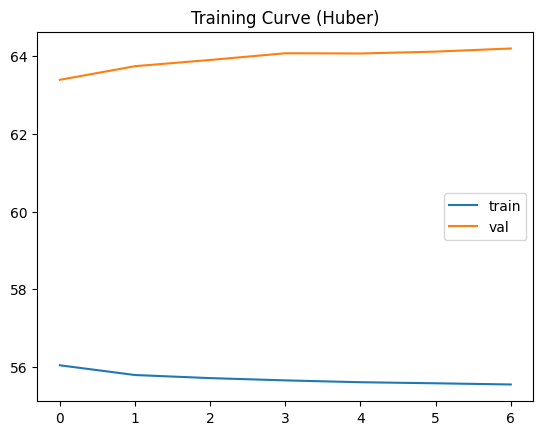

In [ ]:

# 9) Training
early  = keras.callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                       min_delta=0.005, restore_best_weights=True)
reduce = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                           patience=3, min_lr=1e-6)
ckpt   = keras.callbacks.ModelCheckpoint(f"{MODELS_DIR}/best_val_model.keras",
                                         monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=80, batch_size=512,
    callbacks=[early, reduce, ckpt], verbose=1
)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.title('Training Curve (Huber)'); plt.show()


In [ ]:

# 10) Evaluate on TEST and save final model
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(a,b):
    return mean_squared_error(a,b,squared=False)

y_pred = model.predict(X_test_sc)
mae_g  = mean_absolute_error(y_test, y_pred)
rmse_g = rmse(y_test, y_pred)
print(f"GLOBAL — MAE: {mae_g:.3f} | RMSE: {rmse_g:.3f}")

for i, col in enumerate(target_cols):
    mae_i = mean_absolute_error(y_test[:,i], y_pred[:,i])
    rmse_i= rmse(y_test[:,i], y_pred[:,i])
    print(f"{col:20s} — MAE: {mae_i:.3f} | RMSE: {rmse_i:.3f}")

FINAL_DIR = f"{MODELS_DIR}/vanilla_ann_model_softplus"
os.makedirs(FINAL_DIR, exist_ok=True)
model.save(FINAL_DIR)
print('Modelo guardado en:', FINAL_DIR)
